# Project 1 - Movie Recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ast
import warnings
warnings.filterwarnings('ignore')

In [2]:
movies_dir  = "/content/drive/MyDrive/InternWeek4Project1/tmdb_5000_movies.csv"
credits_dir = "/content/drive/MyDrive/InternWeek4Project1/tmdb_5000_credits.csv"

movies  = pd.read_csv(movies_dir)
credits = pd.read_csv(credits_dir)

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
print(movies.head(2))

Movies shape: (4803, 20)
Credits shape: (4803, 4)
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   

                                       homepage     id  \
0                   http://www.avatarmovie.com/  19995   
1  http://disney.go.com/disneypictures/pirates/    285   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   

                                            overview  popularity  \
0  In the 22nd century, a paraplegic Marine is di...  150.437577   
1  Captain Barbossa, long believed to be dead, ha...  139.082615   

   

Merge the datassets

In [3]:
# Merge on title
credits.columns = ['id', 'title', 'cast', 'crew']
movies = movies.merge(credits, on='title')

print("Merged shape:", movies.shape)
print(movies.columns.tolist())

Merged shape: (4809, 23)
['budget', 'genres', 'homepage', 'id_x', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'id_y', 'cast', 'crew']


EDA

budget                     0
genres                     0
homepage                3096
id_x                       0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
id_y                       0
cast                       0
crew                       0
dtype: int64

Basic stats:
             budget       revenue      runtime  vote_average    vote_count
count  4.809000e+03  4.809000e+03  4807.000000   4809.000000   4809.000000
mean   2.902780e+07  8.227511e+07   106.882255      6.092514    690.331670
std    4.070473e+07  1.628379e+08    22.602535      1.193989   1234.187111
min   

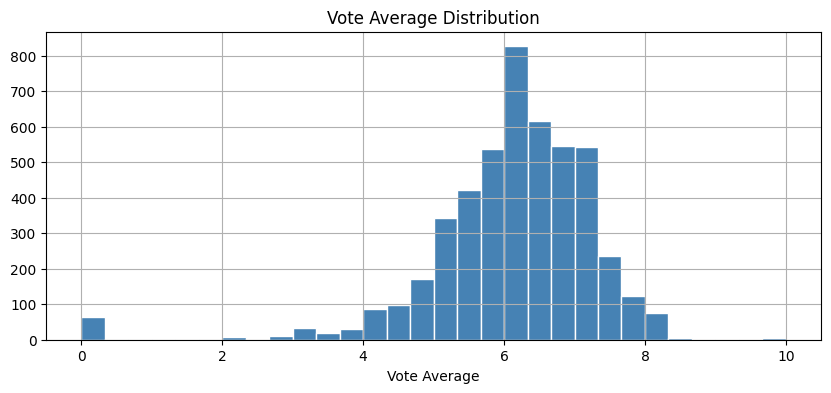

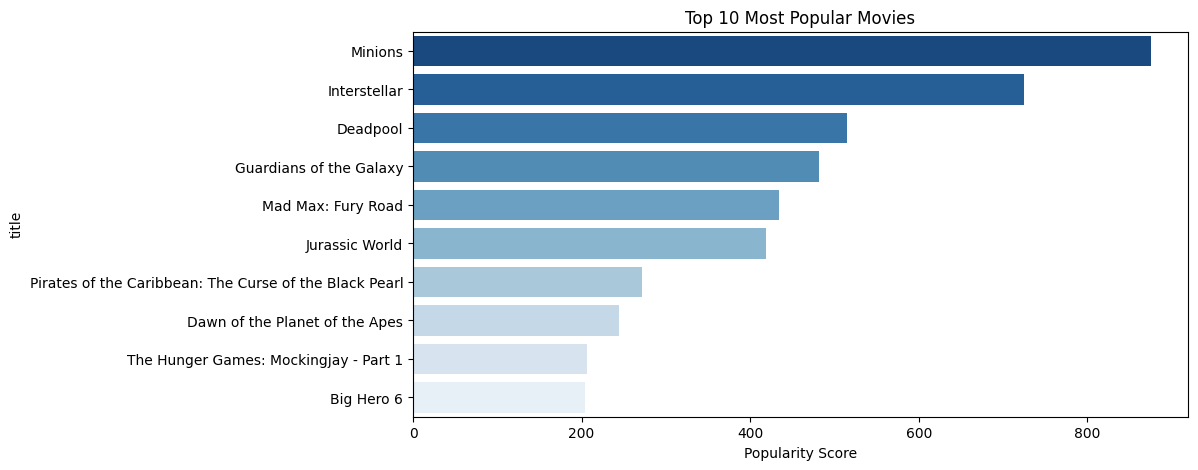

In [4]:
print(movies.isnull().sum())
print("\nBasic stats:")
print(movies[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].describe())

# Top genres
plt.figure(figsize=(10, 4))
movies['vote_average'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Vote Average Distribution')
plt.xlabel('Vote Average')
plt.show()

# Most popular movies
top10 = movies.nlargest(10, 'popularity')[['title', 'popularity']]
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='popularity', y='title', palette='Blues_r')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.show()

Extract meta data features

In [5]:
# Helper functions to parse JSON-like columns
def get_names(obj, key='name', limit=3):
    try:
        items = ast.literal_eval(obj)
        return [i[key] for i in items[:limit]]
    except:
        return []

def get_director(crew):
    try:
        for member in ast.literal_eval(crew):
            if member['job'] == 'Director':
                return [member['name'].replace(" ", "")]
        return []
    except:
        return []

# Extract
movies['genres_list']   = movies['genres'].apply(get_names)
movies['keywords_list'] = movies['keywords'].apply(get_names)
movies['cast_list']     = movies['cast'].apply(lambda x: get_names(x, 'name', 3))
movies['director']      = movies['crew'].apply(get_director)

print(movies[['title', 'genres_list', 'keywords_list', 'cast_list', 'director']].head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                            genres_list  \
0          [Action, Adventure, Fantasy]   
1          [Adventure, Fantasy, Action]   
2            [Action, Adventure, Crime]   
3                [Action, Crime, Drama]   
4  [Action, Adventure, Science Fiction]   

                           keywords_list  \
0     [culture clash, future, space war]   
1     [ocean, drug abuse, exotic island]   
2    [spy, based on novel, secret agent]   
3  [dc comics, crime fighter, terrorist]   
4      [based on novel, mars, medallion]   

                                          cast_list            director  
0  [Sam Worthington, Zoe Saldana, Sigourney Weaver]      [JamesCameron]  
1     [Johnny Depp, Orlando Bloom, Keira Knig

In [6]:
def clean_list(lst):
    return [str(i).lower().replace(" ", "") for i in lst]

movies['genres_list']   = movies['genres_list'].apply(clean_list)
movies['keywords_list'] = movies['keywords_list'].apply(clean_list)
movies['cast_list']     = movies['cast_list'].apply(clean_list)
movies['director']      = movies['director'].apply(clean_list)

# Handle missing overview
movies['overview'] = movies['overview'].fillna('')

# Build soup — combine all text features
def build_soup(row):
    return (
        ' '.join(row['genres_list']) + ' ' +
        ' '.join(row['keywords_list']) + ' ' +
        ' '.join(row['cast_list']) + ' ' +
        ' '.join(row['director']) + ' ' +
        row['overview']
    )

movies['soup'] = movies.apply(build_soup, axis=1)

print(movies[['title', 'soup']].head(2))

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   

                                                soup  
0  action adventure fantasy cultureclash future s...  
1  adventure fantasy action ocean drugabuse exoti...  


 TF-IDF vectorization & cosine similarity

In [7]:
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf.fit_transform(movies['soup'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix shape:", cosine_sim.shape)

TF-IDF matrix shape: (4809, 10000)
Cosine similarity matrix shape: (4809, 4809)


Recommender Function

In [8]:
# Reset index and create title-to-index mapping
movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def get_recommendations(title, n=10):
    # Check if movie exists
    if title not in indices:
        print(f"Movie '{title}' not found in dataset.")
        return None

    idx = indices[title]

    # Get similarity scores for all movies
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude the movie itself (index 0)
    sim_scores = sim_scores[1:n+1]

    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]
    scores        = [round(i[1], 4) for i in sim_scores]

    # Return results
    result = movies[['title', 'genres', 'vote_average']].iloc[movie_indices].copy()
    result['similarity_score'] = scores

    return result.reset_index(drop=True)

Sample Queuries

In [9]:
test_movies = [
    'The Dark Knight',
    'Inception',
    'The Avengers',
    'Toy Story'
]

for movie in test_movies:
    print(f"\n{'='*55}")
    print(f"Movies similar to: {movie}")
    print('='*55)
    result = get_recommendations(movie, n=5)
    if result is not None:
        print(result[['title', 'vote_average', 'similarity_score']].to_string(index=False))


Movies similar to: The Dark Knight
                                  title  vote_average  similarity_score
                  The Dark Knight Rises           7.6            0.3662
Batman: The Dark Knight Returns, Part 2           7.9            0.2710
                         Batman Forever           5.2            0.2468
                         Batman Returns           6.6            0.2456
                          Batman Begins           7.5            0.2304

Movies similar to: Inception
               title  vote_average  similarity_score
             Don Jon           5.9            0.1647
        Premium Rush           6.2            0.1245
            The East           6.5            0.1229
Central Intelligence           6.2            0.1219
              Looper           6.6            0.1203

Movies similar to: The Avengers
                              title  vote_average  similarity_score
            Avengers: Age of Ultron           7.3            0.2594
         Captai

Visualized Similarity

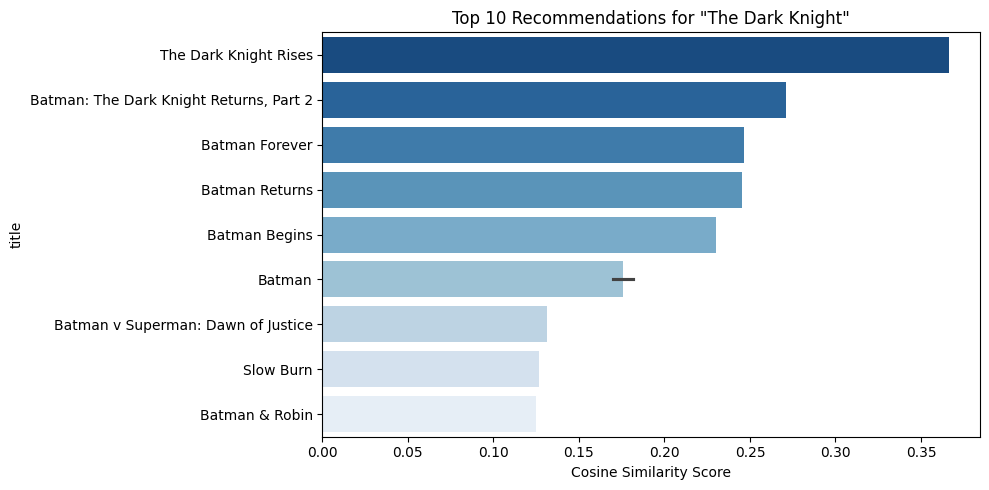

In [10]:
movie_title = 'The Dark Knight'
recs = get_recommendations(movie_title, n=10)

plt.figure(figsize=(10, 5))
sns.barplot(data=recs, x='similarity_score', y='title', palette='Blues_r')
plt.title(f'Top 10 Recommendations for "{movie_title}"')
plt.xlabel('Cosine Similarity Score')
plt.tight_layout()
plt.show()

In [11]:
import joblib

joblib.dump(tfidf,      'recommender_tfidf.pkl')
joblib.dump(cosine_sim, 'recommender_cosine_sim.pkl')

# Save cleaned movies dataframe
movies[['title', 'genres', 'vote_average', 'overview', 'soup']].to_csv(
    'movies_clean.csv', index=False
)

print("Recommender saved.")

Recommender saved.


In [12]:


flask_code = '''
from flask import Flask, request, jsonify
import pandas as pd
import joblib
from sklearn.metrics.pairwise import cosine_similarity

app = Flask(__name__)

# Load saved assets
tfidf      = joblib.load("recommender_tfidf.pkl")
cosine_sim = joblib.load("recommender_cosine_sim.pkl")
movies     = pd.read_csv("movies_clean.csv")
indices    = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

@app.route("/recommend", methods=["GET"])
def recommend():
    title = request.args.get("title", "")
    n     = int(request.args.get("n", 5))

    if title not in indices:
        return jsonify({"error": f"Movie not found: {title}"}), 404

    idx         = indices[title]
    sim_scores  = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    movie_idxs  = [i[0] for i in sim_scores]
    results     = movies["title"].iloc[movie_idxs].tolist()

    return jsonify({"movie": title, "recommendations": results})

if __name__ == "__main__":
    app.run(debug=True)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print("Flask app saved as app.py")
print("Run locally with: python app.py")
print("Then visit: http://127.0.0.1:5000/recommend?title=Inception&n=5")

Flask app saved as app.py
Run locally with: python app.py
Then visit: http://127.0.0.1:5000/recommend?title=Inception&n=5


In [13]:
from google.colab import files

files.download('recommender_tfidf.pkl')
files.download('recommender_cosine_sim.pkl')
files.download('movies_clean.csv')
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>